In [3]:
import os
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.applications import EfficientNetB5
from tensorflow.keras import layers, models
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from imblearn.over_sampling import SMOTE
import pandas as pd
import glob
from sklearn.preprocessing import StandardScaler
from scipy.signal import spectrogram
import sys
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras import backend as K

## Preprocessing

In [5]:
ROOT_DATA_FOLDER = '../data/Wave Data'
NORMAL_FOLDERS = ['A', 'B', 'C', 'D']
SEIZURE_FOLDER = 'E'
FILE_EXTENSION = '*.csv'

SAMPLING_RATE_HZ = 173.33
WINDOW_DURATION_SEC = 10.0
OVERLAP_SEC = 5.0
WINDOW_SIZE = int(WINDOW_DURATION_SEC * SAMPLING_RATE_HZ)
STEP_SIZE = int(OVERLAP_SEC * SAMPLING_RATE_HZ)        

NPERSEG = 128
NOVERLAP = NPERSEG // 2  

VAL_SIZE = 0.15
TEST_SIZE = 0.15
# ----------------------------

def process_files_to_windowed_spectrograms(root_folder, normal_folders, seizure_folder, file_ext, window_size, step_size, fs, nperseg, noverlap):
    all_spectrograms = []
    all_labels = []
    output_shape = None 
    # Normal Folder Preprocessing
    for folder_name in normal_folders:
        folder_path = os.path.join(root_folder, folder_name)
        if not os.path.isdir(folder_path):
            print(f"Warning: Folder not found, skipping: {folder_path}")
            continue
            
        file_paths = glob.glob(os.path.join(folder_path, file_ext))
        print(f"Processing {len(file_paths)} files from {folder_path} (Label 0)...")
        
        if not file_paths:
            print(f"Warning: No files found at {folder_path} with extension {file_ext}")
            
        for file_path in file_paths:
            try:
                signal = pd.read_csv(file_path, header=None, usecols=[1]).values.flatten()
                
                num_windows = (len(signal) - window_size) // step_size + 1
                
                for i in range(num_windows):
                    start = i * step_size
                    end = start + window_size
                    
                    window_signal = signal[start:end]
                    
                    f, t, Sxx = spectrogram(window_signal, fs=fs, nperseg=nperseg, noverlap=noverlap)
                    
                    Sxx_log = np.log1p(Sxx + 1e-6)
                    
                    Sxx_log_reshaped = Sxx_log.reshape(Sxx_log.shape[0], Sxx_log.shape[1], 1)
                    
                    if output_shape is None:
                        output_shape = Sxx_log_reshaped.shape
                        print(f"Detected spectrogram shape (freq, time, channel): {output_shape}")
                    
                    all_spectrograms.append(Sxx_log_reshaped)
                    all_labels.append(0)
                        
            except Exception as e:
                print(f"Warning: Could not process {file_path}. Error: {e}")
                continue
                
    # Seizure Folde Processing
    folder_path = os.path.join(root_folder, seizure_folder)
    if not os.path.isdir(folder_path):
        raise FileNotFoundError(f"Error: Seizure folder not found: {folder_path}")
        
    file_paths = glob.glob(os.path.join(folder_path, file_ext))
    print(f"Processing {len(file_paths)} files from {folder_path} (Label 1)...")
    
    if not file_paths:
        print(f"Warning: No files found at {folder_path} with extension {file_ext}")
        
    for file_path in file_paths:
        try:
            signal = pd.read_csv(file_path, header=None, usecols=[1]).values.flatten()

            num_windows = (len(signal) - window_size) // step_size + 1
            
            for i in range(num_windows):
                start = i * step_size
                end = start + window_size
                window_signal = signal[start:end]
                
                f, t, Sxx = spectrogram(window_signal, fs=fs, nperseg=nperseg, noverlap=noverlap)
                Sxx_log = np.log1p(Sxx + 1e-6)
                Sxx_log_reshaped = Sxx_log.reshape(Sxx_log.shape[0], Sxx_log.shape[1], 1)
                
                all_spectrograms.append(Sxx_log_reshaped)
                all_labels.append(1) # Label 1
                
        except Exception as e:
            print(f"Warning: Could not process {file_path}. Error: {e}")
            continue
            
    if not all_spectrograms:
        raise ValueError("Error: No data was loaded.")
        
    X = np.array(all_spectrograms)
    y = np.array(all_labels)
    
    return X, y, output_shape

def normalize_spectrograms(X_train, X_val, X_test):
    scaler = StandardScaler()
    
    num_samples_train = X_train.shape[0]
    shape_train = X_train.shape[1:]
    X_train_2d = X_train.reshape(num_samples_train, -1)

    num_samples_val = X_val.shape[0]
    shape_val = X_val.shape[1:]
    X_val_2d = X_val.reshape(num_samples_val, -1)

    num_samples_test = X_test.shape[0]
    shape_test = X_test.shape[1:]
    X_test_2d = X_test.reshape(num_samples_test, -1)
    
    scaler.fit(X_train_2d)
    
    X_train_scaled_2d = scaler.transform(X_train_2d)
    X_val_scaled_2d = scaler.transform(X_val_2d)
    X_test_scaled_2d = scaler.transform(X_test_2d)
    
    X_train_scaled = X_train_scaled_2d.reshape(num_samples_train, *shape_train)
    X_val_scaled = X_val_scaled_2d.reshape(num_samples_val, *shape_val)
    X_test_scaled = X_test_scaled_2d.reshape(num_samples_test, *shape_test)

    print("Applied Z-score normalization (fit on train data only).")
    return X_train_scaled, X_val_scaled, X_test_scaled

X, y, spectro_shape = process_files_to_windowed_spectrograms(ROOT_DATA_FOLDER,NORMAL_FOLDERS,SEIZURE_FOLDER,FILE_EXTENSION,WINDOW_SIZE,STEP_SIZE,
    SAMPLING_RATE_HZ,NPERSEG,NOVERLAP)
class_counts = pd.Series(y).value_counts(normalize=True)
    
print(f"Loaded and processed {X.shape[0]} windowed spectrograms.")
print(f"Class balance:\n{class_counts * 100}")

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=(VAL_SIZE + TEST_SIZE), stratify=y, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=(TEST_SIZE / (VAL_SIZE + TEST_SIZE)), stratify=y_temp, random_state=42)

print(f"Segregated data into 70/15/15 split:")
print(f"  X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"  X_val:   {X_val.shape}, y_val:   {y_val.shape}")
print(f"  X_test:  {X_test.shape}, y_test:  {y_test.shape}")

X_train, X_val, X_test = normalize_spectrograms(X_train, X_val, X_test)
    
print("\nPreprocessing complete.")
print("Variables X_train, y_train, X_val, y_val, X_test, y_test are ready.")
print(f"IMPORTANT: Your model input shape is: {spectro_shape}")

Processing 100 files from ../data/Wave Data/A (Label 0)...
Detected spectrogram shape (freq, time, channel): (65, 26, 1)
Processing 100 files from ../data/Wave Data/B (Label 0)...
Processing 100 files from ../data/Wave Data/C (Label 0)...
Processing 100 files from ../data/Wave Data/D (Label 0)...
Processing 100 files from ../data/Wave Data/E (Label 1)...
Loaded and processed 1500 windowed spectrograms.
Class balance:
0    80.0
1    20.0
Name: proportion, dtype: float64
Segregated data into 70/15/15 split:
  X_train: (1050, 65, 26, 1), y_train: (1050,)
  X_val:   (225, 65, 26, 1), y_val:   (225,)
  X_test:  (225, 65, 26, 1), y_test:  (225,)
Applied Z-score normalization (fit on train data only).

Preprocessing complete.
Variables X_train, y_train, X_val, y_val, X_test, y_test are ready.
IMPORTANT: Your model input shape is: (65, 26, 1)


In [6]:
X_flat = X_train.reshape((X_train.shape[0], -1))
smote=SMOTE(sampling_strategy='minority') 
X_train_resampled,y_train_resampled = smote.fit_resample(X_flat,y_train)
X_train = X_train_resampled.reshape((-1, 65, 26, 1))

In [7]:
y_val = np.eye(2)[y_val]
y_test = np.eye(2)[y_test]
y_train = np.eye(2)[y_train_resampled]

## Model Creation

In [9]:
# Activation Function
def squash(vectors, axis=-1):
    s_squared_norm = K.sum(K.square(vectors), axis, keepdims=True)
    scale = s_squared_norm / (1 + s_squared_norm) / K.sqrt(s_squared_norm + K.epsilon())
    return scale * vectors

class CapsuleLayer(layers.Layer):
    def __init__(self, num_capsule, dim_capsule, routings=3, **kwargs):
        super(CapsuleLayer, self).__init__(**kwargs)
        self.num_capsule = num_capsule
        self.dim_capsule = dim_capsule
        self.routings = routings

    def build(self, input_shape):
        self.input_num_capsule = input_shape[1]
        self.input_dim_capsule = input_shape[2]
        self.W = self.add_weight(
            shape=[1, self.input_num_capsule, self.num_capsule, self.dim_capsule, self.input_dim_capsule],
            initializer='glorot_uniform',
            name='W')
        self.built = True

    def call(self, inputs, training=None):
        W_squeezed = K.squeeze(self.W, axis=0)
        u_hat = tf.einsum('bid,ijod->bijo', inputs, W_squeezed)
        b = tf.zeros(shape=[K.shape(u_hat)[0], self.input_num_capsule, self.num_capsule, 1])

        for i in range(self.routings):
            c = layers.Softmax(axis=2)(b)
            s = K.sum(c * u_hat, axis=1, keepdims=True)
            v = squash(s, axis=-1)

            if i < self.routings - 1:
                agreement = K.sum(u_hat * v, axis=-1, keepdims=True)
                b = b + agreement
        
        return K.squeeze(v, axis=1)

    def compute_output_shape(self, input_shape):
        return (input_shape[0], self.num_capsule, self.dim_capsule)



def margin_loss(y_true, y_pred):
    L = K.sqrt(K.sum(K.square(y_pred), axis=-1) + K.epsilon())

    m_plus = 0.9
    m_minus = 0.1
    lambda_ = 0.5
    L_k = y_true * K.square(K.maximum(0., m_plus - L))
    L_k_negative = (1 - y_true) * K.square(K.maximum(0., L - m_minus))
    
    loss = K.sum(L_k + lambda_ * L_k_negative, axis=-1)
    
    return K.mean(loss)


class Length(layers.Layer):
    def call(self, inputs):
        return K.sqrt(K.sum(K.square(inputs), axis=-1) + K.epsilon())

    def compute_output_shape(self, input_shape):
        return input_shape[:-1]

def capsule_accuracy(y_true, y_pred):
    y_pred_lengths = K.sqrt(K.sum(K.square(y_pred), axis=-1) + K.epsilon())
    pred_labels = K.argmax(y_pred_lengths, axis=1)
    true_labels = K.argmax(y_true, axis=1)
    return K.mean(K.equal(true_labels, pred_labels))

def CapsNetHybrid(input_shape, num_classes, num_routings):
    
    inputs = layers.Input(shape=input_shape)
    
    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.BatchNormalization()(x)
    primary_caps = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(x)
    
    num_primary_capsules = (primary_caps.shape[1] * primary_caps.shape[2] * 16)
    primary_caps = layers.Reshape((num_primary_capsules, 8))(primary_caps)
    
    primary_caps_squashed = layers.Lambda(squash)(primary_caps)
    class_capsules = CapsuleLayer(
        num_capsule=num_classes, 
        dim_capsule=16, 
        routings=num_routings
    )(primary_caps_squashed)

    outputs = Length()(class_capsules)
    
    train_model = models.Model(inputs=inputs, outputs=class_capsules)
    eval_model = models.Model(inputs=inputs, outputs=outputs)
    
    return train_model, eval_model

In [10]:
IMG_HEIGHT = 65
IMG_WIDTH = 26
CHANNELS = 1  
NUM_CLASSES = 2  
NUM_ROUTINGS = 3

input_shape = (IMG_HEIGHT, IMG_WIDTH, CHANNELS)
model, eval_model = CapsNetHybrid(input_shape, NUM_CLASSES, NUM_ROUTINGS)

model.summary()
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss=margin_loss,
    metrics=[capsule_accuracy] 
)

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 65, 26, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 65, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 65, 26, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 65, 26, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 13, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 13, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 13, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 6, 128)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 6, 128)     │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 6, 128)     │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 1536, 8)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda (Lambda)                 │ (None, 1536, 8)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ capsule_layer (CapsuleLayer)    │ (None, 2, 16)          │       393,216 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 634,368 (2.42 MB)

 Trainable params: 633,920 (2.42 MB)

 Non-trainable params: 448 (1.75 KB)

In [11]:
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)
checkpoint = ModelCheckpoint(
    '../weights/HybridCapsuelNet_SlidingWindow.weights.h5',
    monitor='val_loss',
    save_best_only=True,
    save_weights_only=True
)

In [12]:
history = model.fit(
    X_train,
    y_train,
    batch_size=16,
    epochs=50,
    validation_data=(X_val, y_val),
    callbacks= [checkpoint, early_stopping]
)

Epoch 1/50
105/105 ━━━━━━━━━━━━━━━━━━━━ 7s 58ms/step - capsule_accuracy: 0.9306 - loss: 0.1212 - val_capsule_accuracy: 0.1875 - val_loss: 0.4485
Epoch 2/50
105/105 ━━━━━━━━━━━━━━━━━━━━ 7s 64ms/step - capsule_accuracy: 0.9846 - loss: 0.0298 - val_capsule_accuracy: 0.1875 - val_loss: 0.5454
Epoch 3/50
105/105 ━━━━━━━━━━━━━━━━━━━━ 7s 63ms/step - capsule_accuracy: 0.9903 - loss: 0.0174 - val_capsule_accuracy: 0.6917 - val_loss: 0.1870
Epoch 4/50
105/105 ━━━━━━━━━━━━━━━━━━━━ 6s 54ms/step - capsule_accuracy: 0.9963 - loss: 0.0085 - val_capsule_accuracy: 0.8583 - val_loss: 0.0786
Epoch 5/50
105/105 ━━━━━━━━━━━━━━━━━━━━ 6s 58ms/step - capsule_accuracy: 0.9960 - loss: 0.0074 - val_capsule_accuracy: 0.9583 - val_loss: 0.0345
Epoch 6/50
105/105 ━━━━━━━━━━━━━━━━━━━━ 6s 58ms/step - capsule_accuracy: 0.9972 - loss: 0.0044 - val_capsule_accuracy: 0.9750 - val_loss: 0.0135
Epoch 7/50
105/105 ━━━━━━━━━━━━━━━━━━━━ 6s 57ms/step - capsule_accuracy: 0.9978 - loss: 0.0039 - val_capsule_accuracy: 0.9917 - va

Plotting training history...


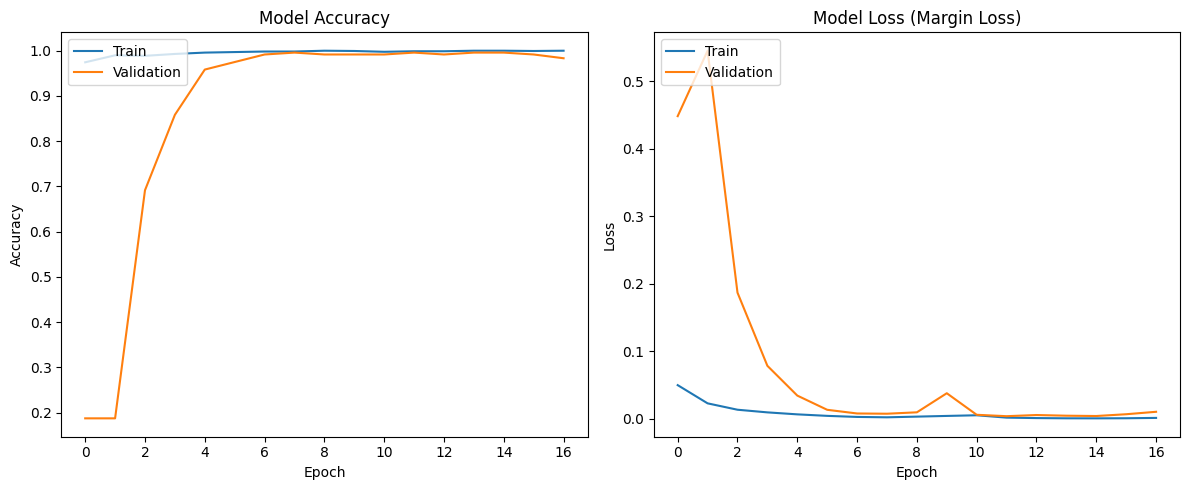

In [14]:
# Add this as a new cell (e.g., Cell 18)

import matplotlib.pyplot as plt

# Check if history was captured
if 'history' in locals():
    print("Plotting training history...")
    
    # Plot training & validation accuracy values
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['capsule_accuracy'])
    plt.plot(history.history['val_capsule_accuracy'])
    plt.title('Model Accuracy')
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Validation'], loc='upper left')

    # Plot training & validation loss values
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title('Model Loss (Margin Loss)')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Validation'], loc='upper left')

    plt.tight_layout()
    plt.show()

else:
    print("Warning: 'history' variable not found.")
    print("Please re-run the 'model.fit' cell after modifying it to 'history = model.fit(...)'")

In [21]:
model.load_weights('../weights/HybridCapsuelNet_SlidingWindow.weights.h5')
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f"Test Loss: {test_loss}")
print(f"Test Accuracy: {test_accuracy}")

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - capsule_accuracy: 0.9936 - loss: 0.0062    
Test Loss: 0.004645597655326128
Test Accuracy: 0.99609375


In [22]:
y_pred_lengths = eval_model.predict(X_test)
y_pred_classes = np.argmax(y_pred_lengths, axis=1)

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step 


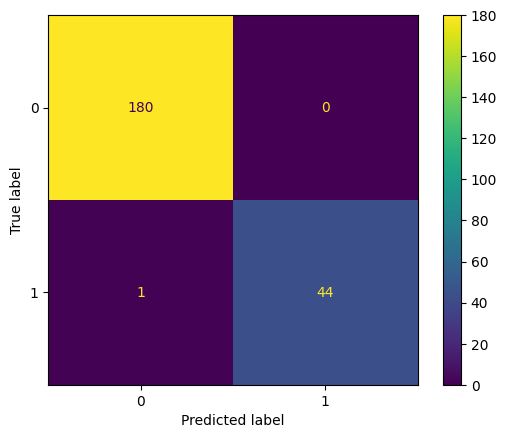

In [23]:
if y_test.ndim > 1:
    y_test_classes = np.argmax(y_test, axis=1)
else:
    y_test_classes = y_test

# Compute confusion matrix
cm = confusion_matrix(y_test_classes, y_pred_classes)

# Display confusion matrix
cm_display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
cm_display.plot()

In [24]:
# Add this as a new cell (e.g., Cell 25)

from sklearn.metrics import classification_report

print("\n--- Classification Report ---")

# Define target names for clarity
target_names = ['Class 0 (Normal)', 'Class 1 (Seizure)']

# Print the classification report
print(classification_report(y_test_classes, y_pred_classes, target_names=target_names))


--- Classification Report ---
                   precision    recall  f1-score   support

 Class 0 (Normal)       0.99      1.00      1.00       180
Class 1 (Seizure)       1.00      0.98      0.99        45

         accuracy                           1.00       225
        macro avg       1.00      0.99      0.99       225
     weighted avg       1.00      1.00      1.00       225



In [25]:
from art.attacks.evasion import FastGradientMethod
from art.estimators.classification import TensorFlowV2Classifier
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

In [33]:
import tensorflow.keras.backend as K
import tensorflow as tf

# Define a margin loss that works on the *lengths* output of eval_model
# This is required for the ART wrapper.
def loss_fn_on_lengths(y_true_one_hot, y_pred_lengths):
    # y_true_one_hot shape: (None, 2)
    # y_pred_lengths shape: (None, 2)
    L = y_true_one_hot * K.square(K.maximum(0., 0.9 - y_pred_lengths)) + \
        0.5 * (1 - y_true_one_hot) * K.square(K.maximum(0., y_pred_lengths - 0.1))
    
    return K.mean(K.sum(L, axis=1))

In [35]:
# 1. Get the min/max values from your normalized test data (from Cell 4)
clip_min = X_test.min()
clip_max = X_test.max()

# 2. Wrap your 'eval_model' (which outputs the lengths)
# We provide the new loss function that works on lengths.
art_classifier = TensorFlowV2Classifier(
    model=eval_model,
    nb_classes=2,
    input_shape=(65, 26, 1),
    loss_object=loss_fn_on_lengths,  # Use the loss function we just defined
    clip_values=(clip_min, clip_max)
)

In [37]:
# 1. Create the FGM attack
attack_fgm = FastGradientMethod(estimator=art_classifier, eps=0.1)

# 2. Generate adversarial examples from your clean X_test
print("Generating adversarial examples for eps=0.1...")
X_test_adv = attack_fgm.generate(x=X_test)
print("Generation complete.")

# 3. Evaluate on CLEAN data (Baseline)
preds_clean = eval_model.predict(X_test)
preds_clean_classes = np.argmax(preds_clean, axis=1)
y_test_classes = np.argmax(y_test, axis=1) # Convert one-hot y_test to labels

acc_clean = np.mean(preds_clean_classes == y_test_classes)
print(f"\nAccuracy on CLEAN data (Baseline):   {acc_clean * 100:.2f}%")

# 4. Evaluate on ADVERSARIAL data
preds_adv = eval_model.predict(X_test_adv)
preds_adv_classes = np.argmax(preds_adv, axis=1)

acc_adv = np.mean(preds_adv_classes == y_test_classes)
print(f"Accuracy on ADVERSARIAL data (FGM):  {acc_adv * 100:.2f}%")

Generating adversarial examples for eps=0.1...
Generation complete.
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step

Accuracy on CLEAN data (Baseline):   99.56%
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
Accuracy on ADVERSARIAL data (FGM):  98.22%


Evaluating model robustness across different eps values...
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
eps=0.000 → Accuracy=99.56%
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
eps=0.033 → Accuracy=99.56%
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
eps=0.067 → Accuracy=99.11%
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
eps=0.100 → Accuracy=98.22%
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
eps=0.133 → Accuracy=97.78%
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
eps=0.167 → Accuracy=96.89%
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
eps=0.200 → Accuracy=96.44%
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
eps=0.233 → Accuracy=96.44%
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
eps=0.267 → Accuracy=96.00%
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
eps=0.300 → Accuracy=96.00%

Baseline accuracy on CLEAN data: 99.56%


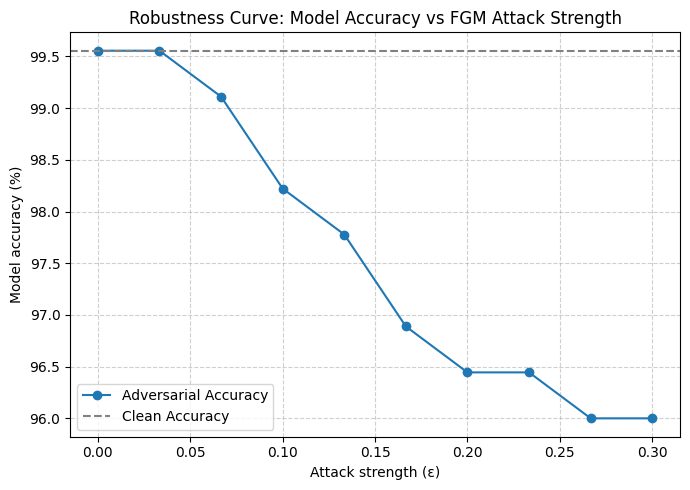

In [39]:
# Define a range of attack strengths
eps_values = np.linspace(0, 0.3, 10)
accuracies = []
y_test_classes = np.argmax(y_test, axis=1) # Ensure y_test is 1D labels

print("Evaluating model robustness across different eps values...")

for eps in eps_values:
    # Set the attack strength
    attack_fgm.set_params(eps=eps)
    
    # Generate new adversarial examples
    X_test_adv = attack_fgm.generate(x=X_test)
    
    # Evaluate on the new adversarial data
    preds_adv = eval_model.predict(X_test_adv)
    preds_adv_classes = np.argmax(preds_adv, axis=1)
    
    acc_adv = np.mean(preds_adv_classes == y_test_classes)
    accuracies.append(acc_adv)
    print(f"eps={eps:.3f} → Accuracy={acc_adv*100:.2f}%")

print(f"\nBaseline accuracy on CLEAN data: {accuracies[0]*100:.2f}%")

# === Plot robustness curve ===
plt.figure(figsize=(7, 5))
plt.plot(eps_values, np.array(accuracies) * 100, marker='o', label='Adversarial Accuracy')
plt.axhline(accuracies[0] * 100, color='gray', linestyle='--', label='Clean Accuracy')
plt.xlabel("Attack strength (ε)")
plt.ylabel("Model accuracy (%)")
plt.title("Robustness Curve: Model Accuracy vs FGM Attack Strength")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()